In [1]:
import xarray as xr

### CM4

In [2]:
data = xr.open_zarr(
    "/pscratch/sd/s/suryad/data/cm4_piControl_ocean_200yr_full_chunked.zarr", chunks={}
)
# cm4_piControl_ocean_200yr_full_chunked.zarr
data

<xarray.Dataset> Size: 458GB
Dimensions:               (time: 14600, lat: 180, lon: 360)
Coordinates:
  * lat                   (lat) float64 1kB -89.24 -88.25 -87.25 ... 88.25 89.24
  * lon                   (lon) float64 3kB 0.5 1.5 2.5 ... 357.5 358.5 359.5
  * time                  (time) object 117kB 0151-01-06 00:00:00 ... 0351-01...
Data variables: (12/141)
    EXT                   (time, lat, lon) float32 4GB dask.array<chunksize=(10, 180, 360), meta=np.ndarray>
    HI                    (time, lat, lon) float32 4GB dask.array<chunksize=(10, 180, 360), meta=np.ndarray>
    HS                    (time, lat, lon) float32 4GB dask.array<chunksize=(10, 180, 360), meta=np.ndarray>
    UI                    (time, lat, lon) float32 4GB dask.array<chunksize=(10, 180, 360), meta=np.ndarray>
    VI                    (time, lat, lon) float32 4GB dask.array<chunksize=(10, 180, 360), meta=np.ndarray>
    evs                   (time, lat, lon) float32 4GB dask.array<chunksize=(10, 180, 360), meta=np.ndarray>
    ...                    ...
    vo_6                  (time, lat, lon) float32 4GB dask.array<chunksize=(10, 180, 360), meta=np.ndarray>
    vo_7                  (time, lat, lon) float32 4GB dask.array<chunksize=(10, 180, 360), meta=np.ndarray>
    vo_8                  (time, lat, lon) float32 4GB dask.array<chunksize=(10, 180, 360), meta=np.ndarray>
    vo_9                  (time, lat, lon) float32 4GB dask.array<chunksize=(10, 180, 360), meta=np.ndarray>
    wfo                   (time, lat, lon) float32 4GB dask.array<chunksize=(10, 180, 360), meta=np.ndarray>
    zos                   (time, lat, lon) float32 4GB dask.array<chunksize=(10, 180, 360), meta=np.ndarray>
Attributes:
    history:        Dataset computed by full-model/scripts/data_process/compu...
    regrid_method:  conservative

In [3]:
sea_surface_fraction = data["sea_surface_fraction"]

In [4]:
# data = data.isel(time=slice(None, 100))

In [5]:
old_data = xr.open_zarr(
    "/global/cfs/cdirs/m4874/suryad/data/CM4_5daily_v0.4.0_preprocessed.zarr", chunks={}
)

In [6]:
v = "mask"
levels = old_data.lev.values
level_numbers = [i for i in range(19)]
sorted_vars = [v + "_" + str(lev) for lev in level_numbers]
mask = xr.concat([data[var] for var in sorted_vars], dim="lev")
mask = mask.assign_coords(lev=levels)

In [7]:
v = "thetao"
levels = old_data.lev.values
level_numbers = [i for i in range(19)]
sorted_vars = [v + "_" + str(lev) for lev in level_numbers]
thetao = xr.concat([data[var] for var in sorted_vars], dim="lev")
thetao = thetao.assign_coords(lev=levels)
thetao = thetao.rename("thetao")
# areacello = spherical_area_weights(thetao)
thetao = thetao.transpose("time", "lev", ...)
thetao["areacello"] = (["lat", "lon"], old_data.areacello.values)
thetao["dz"] = ("lev", old_data.dz.values)

In [8]:
hfds = data["hfds"].fillna(0)
hfgeou = data["hfgeou"].isel(time=0).fillna(0)
ssf = data["sea_surface_fraction"].isel(time=0).fillna(0)

In [9]:
c_p = 3850  # J/(kg C)
rho_0 = 1025  # kg/m^3

OHC = (
    ((thetao * c_p * rho_0) * thetao["areacello"] * thetao["dz"])
    .sum(["lat", "lon", "lev"])
    .compute()
)
OHC = OHC.rename("OHC")
OHC = OHC.assign_attrs(units="J")

In [10]:
time = 5 * 24 * 60 * 60
hfds_int = (
    (hfds.cumsum("time") * thetao["areacello"] * time).sum(["lat", "lon"]).compute()
)

In [11]:
time = 5 * 24 * 60 * 60
hfds_geo_int = (
    ((hfds + hfgeou).cumsum("time") * thetao["areacello"] * time)
    .sum(["lat", "lon"])
    .compute()
)

In [12]:
time = 5 * 24 * 60 * 60
hfds_geo_seafrac_int = (
    ((hfds * ssf + hfgeou).cumsum("time") * thetao["areacello"] * time)
    .sum(["lat", "lon"])
    .compute()
)

In [31]:
time = 5 * 24 * 60 * 60
hfds_geo_seafrac2_int = (
    ((hfds * ssf + hfgeou * ssf).cumsum("time") * thetao["areacello"] * time)
    .sum(["lat", "lon"])
    .compute()
)

In [14]:
time = 5 * 24 * 60 * 60
hfds_seafrac_geo_seafloor_int = (
    (
        (hfds * ssf + hfgeou * mask.isel(lev=-1, time=0)).cumsum("time")
        * thetao["areacello"]
        * time
    )
    .sum(["lat", "lon"])
    .compute()
)

In [39]:
time = 5 * 24 * 60 * 60
hfds_geo_seafrac3_int = (
    ((hfds * ssf + hfgeou * ssf).cumsum("time") * thetao["areacello"] * time)
    .sum(["lat", "lon"])
    .compute()
)

In [40]:
time_slice = slice(None, 146)

In this plot, we correct our model to fit the red line - CM4 HFDS (with sea surface fraction) + Geothermal and "optimizing" for the blue line. We are not REALLY optimizing since we are only optimizing for next step prediction and no global ocean heat loss consideration

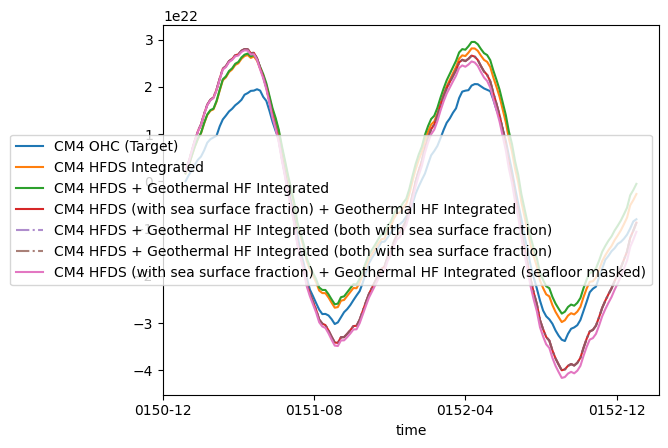

In [41]:
import matplotlib.pyplot as plt

(OHC.isel(time=time_slice) - OHC.isel(time=0)).plot(label="CM4 OHC (Target)")
hfds_int.isel(time=time_slice).plot(label="CM4 HFDS Integrated")
hfds_geo_int.isel(time=time_slice).plot(label="CM4 HFDS + Geothermal HF Integrated")
hfds_geo_seafrac_int.isel(time=time_slice).plot(
    label="CM4 HFDS (with sea surface fraction) + Geothermal HF Integrated"
)
hfds_geo_seafrac2_int.isel(time=time_slice).plot(
    label="CM4 HFDS + Geothermal HF Integrated (both with sea surface fraction)",
    alpha=0.75,
    ls="-.",
)
hfds_geo_seafrac3_int.isel(time=time_slice).plot(
    label="CM4 HFDS + Geothermal HF Integrated (both with sea surface fraction)",
    alpha=0.75,
    ls="-.",
)
hfds_seafrac_geo_seafloor_int.isel(time=time_slice).plot(
    label="CM4 HFDS (with sea surface fraction) + Geothermal HF Integrated (seafloor masked)"
)
plt.title("")
plt.ylabel("")
plt.legend()
plt.show()

### OM4

In [119]:
data = xr.open_zarr(
    "/pscratch/sd/s/suryad/data/3D_data_OM4_5daily_v0.2.1_with_hfds_anomalies",
    chunks={},
)
# cm4_piControl_ocean_200yr_full_chunked.zarr
data

<xarray.Dataset> Size: 100GB
Dimensions:            (y: 180, x: 360, lev: 19, time: 4745, y_b: 181, x_b: 361)
Coordinates:
    areacello          (y, x) float64 518kB dask.array<chunksize=(90, 360), meta=np.ndarray>
    dz                 (lev) int64 152B dask.array<chunksize=(19,), meta=np.ndarray>
    lat                (y, x) float64 518kB dask.array<chunksize=(90, 360), meta=np.ndarray>
    lat_b              (y_b, x_b) float64 523kB dask.array<chunksize=(91, 361), meta=np.ndarray>
  * lev                (lev) float64 152B 2.5 10.0 22.5 ... 4e+03 5e+03 6e+03
    lon                (y, x) float64 518kB dask.array<chunksize=(90, 360), meta=np.ndarray>
    lon_b              (y_b, x_b) float64 523kB dask.array<chunksize=(91, 361), meta=np.ndarray>
    ocean_fraction     (lev, y, x) float64 10MB dask.array<chunksize=(19, 180, 360), meta=np.ndarray>
  * time               (time) object 38kB 1958-01-03 12:00:00 ... 2022-12-29 ...
    wetmask            (lev, y, x) bool 1MB dask.array<chunksize=(10, 90, 360), meta=np.ndarray>
  * x                  (x) float64 3kB 0.5 1.5 2.5 3.5 ... 357.5 358.5 359.5
  * y                  (y) float64 1kB -89.24 -88.25 -87.25 ... 88.25 89.24
Dimensions without coordinates: y_b, x_b
Data variables: (12/81)
    hfds               (time, y, x) float32 1GB dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    hfds_anomalies     (time, y, x) float32 1GB dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    so_lev_1050_0      (time, y, x) float32 1GB dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    so_lev_105_0       (time, y, x) float32 1GB dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    so_lev_10_0        (time, y, x) float32 1GB dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    so_lev_1400_0      (time, y, x) float32 1GB dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    ...                 ...
    vo_lev_5000_0      (time, y, x) float32 1GB dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    vo_lev_550_0       (time, y, x) float32 1GB dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    vo_lev_6000_0      (time, y, x) float32 1GB dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    vo_lev_65_0        (time, y, x) float32 1GB dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    vo_lev_775_0       (time, y, x) float32 1GB dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    zos                (time, y, x) float32 1GB dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
Attributes:
    m2lines/ocean-emulators_git_hash:  https://github.com/m2lines/ocean_emula...
    regrid_method:                     conservative

In [120]:
data = data.rename({"lon": "lon_t", "lat": "lat_t"})
data = data.rename({"x": "lon", "y": "lat"})

In [121]:
v = "thetao"
levels = old_data.lev.values
sorted_vars = [v + "_lev_" + str(lev).replace(".", "_") for lev in levels]
thetao = xr.concat([data[var] for var in sorted_vars], dim="lev")
thetao = thetao.assign_coords(lev=levels)
thetao = thetao.rename("thetao")
# areacello = spherical_area_weights(thetao)
thetao = thetao.transpose("time", "lev", ...)
thetao["areacello"] = (["lat", "lon"], old_data.areacello.values)
thetao["dz"] = ("lev", old_data.dz.values)

In [124]:
hfds = data["hfds"].fillna(0)

In [125]:
c_p = 3850  # J/(kg C)
rho_0 = 1025  # kg/m^3

OHC = (
    ((thetao * c_p * rho_0) * thetao["areacello"] * thetao["dz"])
    .sum(["lat", "lon", "lev"])
    .compute()
)
OHC = OHC.rename("OHC")
OHC = OHC.assign_attrs(units="J")

In [126]:
time = 5 * 24 * 60 * 60
hfds_int = (
    (hfds.cumsum("time") * thetao["areacello"] * time).sum(["lat", "lon"]).compute()
)

In [127]:
time = 5 * 24 * 60 * 60
hfds_geo_int = (
    ((hfds + hfgeou).cumsum("time") * thetao["areacello"] * time)
    .sum(["lat", "lon"])
    .compute()
)

In [128]:
time = 5 * 24 * 60 * 60
hfds_geo_seafrac_int = (
    ((hfds * ssf + hfgeou).cumsum("time") * thetao["areacello"] * time)
    .sum(["lat", "lon"])
    .compute()
)

In [129]:
time = 5 * 24 * 60 * 60
hfds_geo_seafrac2_int = (
    ((hfds * ssf + hfgeou * ssf).cumsum("time") * thetao["areacello"] * time)
    .sum(["lat", "lon"])
    .compute()
)

In [130]:
time = 5 * 24 * 60 * 60
hfds_seafrac_geo_seafloor_int = (
    (
        (hfds * ssf + hfgeou * mask.isel(lev=-1, time=0)).cumsum("time")
        * thetao["areacello"]
        * time
    )
    .sum(["lat", "lon"])
    .compute()
)

In [131]:
time_slice = slice(None, None)

In this plot, we correct our model to fit the red line - CM4 HFDS (with sea surface fraction) + Geothermal and "optimizing" for the blue line. We are not REALLY optimizing since we are only optimizing for next step prediction and no global ocean heat loss consideration

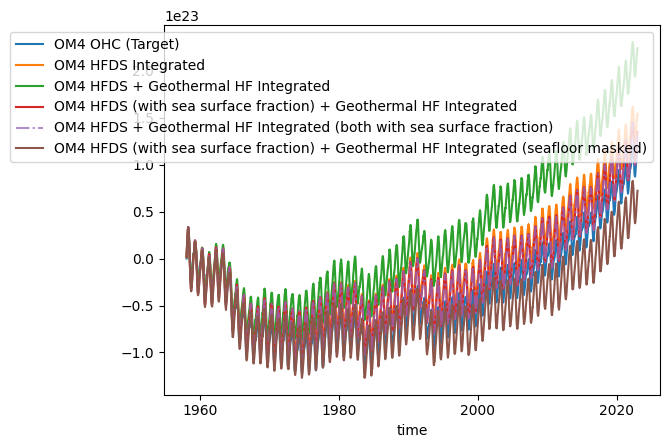

In [133]:
import matplotlib.pyplot as plt

(OHC.isel(time=time_slice) - OHC.isel(time=0)).plot(label="OM4 OHC (Target)")
hfds_int.isel(time=time_slice).plot(label="OM4 HFDS Integrated")
hfds_geo_int.isel(time=time_slice).plot(label="OM4 HFDS + Geothermal HF Integrated")
hfds_geo_seafrac_int.isel(time=time_slice).plot(
    label="OM4 HFDS (with sea surface fraction) + Geothermal HF Integrated"
)
hfds_geo_seafrac2_int.isel(time=time_slice).plot(
    label="OM4 HFDS + Geothermal HF Integrated (both with sea surface fraction)",
    alpha=0.75,
    ls="-.",
)
hfds_seafrac_geo_seafloor_int.isel(time=time_slice).plot(
    label="OM4 HFDS (with sea surface fraction) + Geothermal HF Integrated (seafloor masked)"
)
plt.title("")
plt.ylabel("")
plt.legend()
plt.show()

### Check sea_surface_fraction and hfgeou

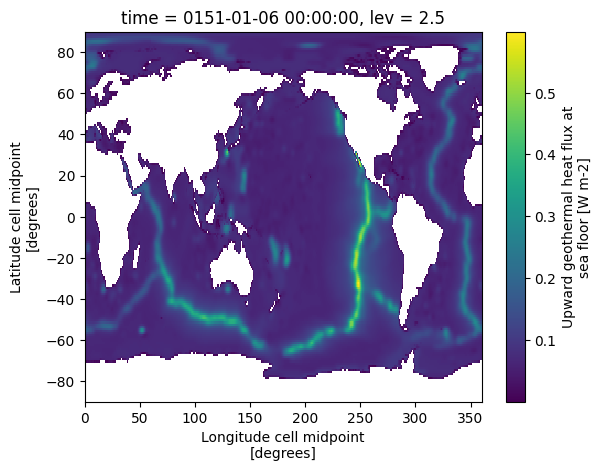

In [122]:
hfgeou.isel(time=0).plot()

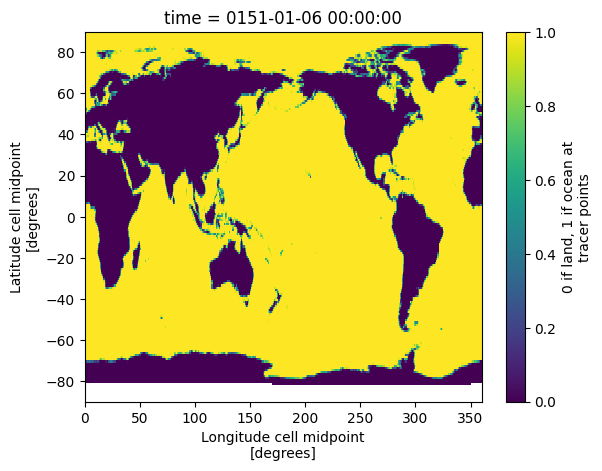

In [123]:
sea_surface_fraction.isel(time=0).plot()

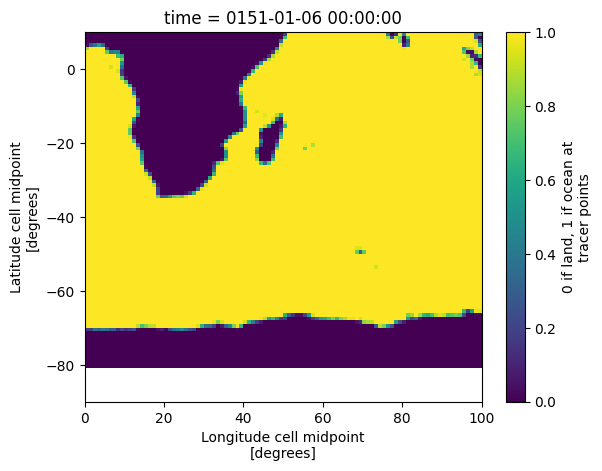

In [128]:
sea_surface_fraction.isel(time=0, lon=slice(None, 100), lat=slice(None, 100)).plot()

In [139]:
import numpy as np

ls = np.unique(sea_surface_fraction.isel(time=0).values)
ls[len(ls) // 2]

0.5610218

#### Check if sea surface fraction is fixed constant across time

In [144]:
ssf_0 = sea_surface_fraction.isel(time=0)
for i in range(1, sea_surface_fraction.time.size):
    assert (
        sea_surface_fraction.isel(time=i).fillna(0).values == ssf_0.fillna(0).values
    ).all()

In [150]:
ssf_0.to_zarr(
    "/pscratch/sd/s/suryad/data/cm4_sea_surface_fraction_fixed.zarr",
    mode="w",
    encoding={ssf_0.name: {"compressor": None}},
)

#### Check if geothermal hf is fixed constant across time

In [154]:
hfgeou_0 = hfgeou.isel(time=0)
for i in range(1, hfgeou.time.size):
    assert (hfgeou.isel(time=i).fillna(0).values == hfgeou_0.fillna(0).values).all()

In [155]:
hfgeou_0.to_zarr(
    "/pscratch/sd/s/suryad/data/cm4_geothermal_hf_fixed.zarr",
    mode="w",
    encoding={hfgeou_0.name: {"compressor": None}},
)